# ¿Por Qué Fallan los Transformers en PINNs? Diagnóstico y Experimentos Favorables

> **Contexto:** El notebook anterior (`Pruebas_Transformer_PINN`) demostró que tanto el PIT como el PINNsFormer fallan sistemáticamente frente al MLP en todos los experimentos. Este cuaderno analiza las causas raíz de ese fracaso y diseña experimentos donde los Transformers tienen ventajas teóricas genuinas.

---

## Estructura del Cuaderno

| Sección | Contenido |
|---|---|
| **A. Diagnóstico** | Tres bugs fundamentales identificados en el notebook anterior |
| **Experimento 1** | Ecuación de difusión no-local (Fredholm): atención ≈ operador integral |
| **Experimento 2** | Advección lineal con Transformer causal: respeto de la causalidad temporal |
| **Resumen** | Tabla comparativa y guía de cuándo usar cada arquitectura |

---
# SECCIÓN A: DIAGNÓSTICO — Por Qué Fallaron los Transformers

## Bug 1 (Crítico): Contaminación de Gradientes en el PIT

El PIT trata el batch completo de $N$ puntos de colocación como una secuencia y los pasa **conjuntamente** por el mecanismo de auto-atención. Esto genera un bug matemático fundamental en el cómputo del residuo físico.

En el mecanismo de atención, la predicción en el punto $x_i$ queda acoplada a **todos** los demás puntos:

$$\hat{u}(x_i) = \sum_{j=1}^N \alpha_{ij} \cdot v_j, \quad \alpha_{ij} = \text{softmax}\left(\frac{q_i k_j^T}{\sqrt{d_k}}\right)$$

Esto significa que $\hat{u}(x_i) = f(x_1, x_2, \ldots, x_N)$, es decir, **depende de todos los puntos simultáneamente**.

Cuando el autograd de PyTorch calcula $\partial \hat{u}(x_i)/\partial x_i$ para el residuo de la EDP, obtiene:

$$\frac{\partial}{\partial x_i}\left[\sum_j \alpha_{ij}(x_1,\ldots,x_N) \cdot v_j(x_1,\ldots,x_N)\right] \neq \left.\frac{\partial u}{\partial x}\right|_{x_i}$$

Lo que se obtiene **NO es la derivada espacial de la solución** en $x_i$, sino el jacobiano de una función que mezcla todos los puntos del dominio. El residuo físico queda completamente corrompido.

In [14]:
import torch
import torch.nn as nn
import numpy as np

# ────────────────────────────────────────────────────────────────────────────
# DEMOSTRACIÓN DEL BUG: Contaminación de gradientes en atención global
# ────────────────────────────────────────────────────────────────────────────

# Función de referencia: u(x) = x³  →  du/dx = 3x²
# En x=0.5: du/dx = 0.75

# ── Caso A: MLP puntual (correcto) ─────────────────────────────────────────
x1 = torch.tensor([[0.5]], requires_grad=True)
u1_mlp = x1 ** 3
grad_mlp = torch.autograd.grad(u1_mlp, x1)[0].item()

# ── Caso B: Transformer con atención global (incorrecto para EDPs locales) ──
x2 = torch.tensor([[0.8]], requires_grad=True)   # Segundo punto del batch
x_batch = torch.cat([x1, x2], dim=0)             # (2, 1): ambos puntos juntos

# Atención simplificada: score = x_i·x_j, pesos = softmax
scores = (x_batch @ x_batch.T) / (1.0 ** 0.5)   # (2, 2)
attn_w = torch.softmax(scores, dim=-1)            # (2, 2)
u_attn = attn_w @ x_batch                        # (2, 1): mezcla de x1 y x2

# Tomamos la predicción para el primer punto y diferenciamos
u1_attn = u_attn[0:1]
grad_wrt_x1 = torch.autograd.grad(u1_attn, x1, retain_graph=True)[0].item()
grad_wrt_x2 = torch.autograd.grad(u1_attn, x2)[0].item()  # ← Este debería ser 0!

print('='*65)
print('  DEMOSTRACIÓN: Contaminación de Gradientes en PIT')
print('='*65)
print(f'  Derivada exacta  du/dx en x=0.5         : 0.7500 (3x²)')
print(f'  MLP  ∂u₁/∂x₁                             : {grad_mlp:.4f}  ✓ (depende solo de x₁)')
print(f'  PIT  ∂u₁/∂x₁ (vía atención)              : {grad_wrt_x1:.4f}')
print(f'  PIT  ∂u₁/∂x₂ (DEBERÍA SER 0)             : {grad_wrt_x2:.4f}  ✗ (contaminado por x₂!)')
print()
print('  → El PIT incluye la influencia de x₂ en el residuo de x₁.')
print('  → El residuo físico queda corrompido: la EDP se satisface en ningún punto.')
print('='*65)

  DEMOSTRACIÓN: Contaminación de Gradientes en PIT
  Derivada exacta  du/dx en x=0.5         : 0.7500 (3x²)
  MLP  ∂u₁/∂x₁                             : 0.7500  ✓ (depende solo de x₁)
  PIT  ∂u₁/∂x₁ (vía atención)              : 0.4477
  PIT  ∂u₁/∂x₂ (DEBERÍA SER 0)             : 0.5747  ✗ (contaminado por x₂!)

  → El PIT incluye la influencia de x₂ en el residuo de x₁.
  → El residuo físico queda corrompido: la EDP se satisface en ningún punto.


## Bug 2: Desequilibrio de Parámetros (12:1)

Del notebook anterior:
```
MLP-PINN (baseline)            8,385 parámetros
PIT (atención global)        100,481 parámetros   ← 12x más
PINNsFormer (seq gen)        100,993 parámetros   ← 12x más
```

El MLP es 12 veces más compacto y, aun así, **supera a los Transformers**. Esto invalida la comparación: no es una victoria del MLP sobre los Transformers, sino del modelo pequeño y apropiado sobre modelos sobredimensionados.

## Bug 3: RFF σ=10 Forzado en Todos los Experimentos

Las **Random Fourier Features** con $\sigma=10$ inyectan bases de alta frecuencia en la entrada:

$$\gamma(x) = [\sin(10 \cdot B_1 x), \cos(10 \cdot B_1 x), \ldots, \sin(10 \cdot B_{d/2} x), \cos(10 \cdot B_{d/2} x)]$$

Esto es correcto para Helmholtz ($k=10$), pero **activamente perjudicial** para la advección-difusión, cuya solución es monótona y suave ($u \in [0,1]$). Intentar construir una función plana con bases de Fourier de alta frecuencia induce el **fenómeno de Gibbs**, generando oscilaciones espurias. El MLP con $\tanh$ no sufre este problema porque sus activaciones son globalmente suaves.

## Bug 4 (Burgers): Viscosidad Artificial como Atajo de Optimización

En Burgers, el PIT obtuvo una loss final muy baja ($6.6 \times 10^{-5}$) pero una solución visualmente incorrecta. El mecanismo de atención actúa como un **filtro de suavizado espacial**: al promediar las contribuciones de todos los puntos, el Transformer aprende a "difuminar" el frente de choque, reduciendo los gradientes de segundo orden y, con ello, la magnitud del residuo. Optimiza hacia una solución matemáticamente barata pero físicamente falsa.

---
# SECCIÓN B: SETUP COMÚN

Establecemos un entorno reproducible y comparaciones **estrictamente justas** (mismos parámetros, mismo número de épocas, mismo dato).

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Hardware ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU        : {torch.cuda.get_device_name(0)}')

# ── Semillas ──────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# ── Utilidades ────────────────────────────────────────────────────────────────
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def rel_l2(u_pred: np.ndarray, u_exact: np.ndarray) -> float:
    """Error relativo en norma L2."""
    return np.linalg.norm(u_pred - u_exact) / (np.linalg.norm(u_exact) + 1e-14)

def train(
    model: nn.Module,
    loss_fn,
    name: str,
    epochs: int = 5000,
    lr: float = 5e-4,
    clip: float = 1.0,
) -> list:
    """Bucle de entrenamiento genérico con Adam + scheduler."""
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    history = []

    pbar = tqdm(range(epochs), desc=f'[{name}]', leave=True)
    for ep in pbar:
        model.train()
        opt.zero_grad()
        loss = loss_fn(model)
        loss.backward()
        if clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        sched.step()
        history.append(loss.item())
        if ep % 500 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.2e}', 'lr': f'{sched.get_last_lr()[0]:.1e}'})

    print(f'  [{name}] Loss final: {history[-1]:.3e}')
    return history

print('Setup completado.')

Dispositivo: cpu
Setup completado.


## Definición de Arquitecturas

Definimos cuatro arquitecturas con **número de parámetros equilibrado** (~9K cada una):

| Arquitectura | Uso | Inductive Bias |
|---|---|---|
| `MLP_PINN` | Baseline | Aproximación puntual universal |
| `NonlocalTransformerPINN` | Exp. 1 | Atención global ≈ operador integral |
| `CausalTransformerPINN` | Exp. 2 | Atención causal en tiempo |

### Clave del diseño correcto

- **`NonlocalTransformerPINN`**: procesa todos los puntos juntos **sin necesitar derivadas** (ecuación integral, no diferencial). La atención es el mecanismo físicamente correcto.
- **`CausalTransformerPINN`**: aplica una máscara triangular inferior que garantiza que el punto $(x_i, t_i)$ solo atiende a puntos con $t_j \leq t_i$. Respeta la flecha del tiempo.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  1.  MLP-PINN estándar (baseline)
# ─────────────────────────────────────────────────────────────────────────────
class MLP_PINN(nn.Module):
    """MLP tanh estándar, procesamiento puntual e independiente."""
    def __init__(self, layers: list):
        super().__init__()
        mods = []
        for i in range(len(layers) - 2):
            mods += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        mods.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*mods)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
#  2.  Nonlocal Transformer (para ecuaciones integrales, Experimento 1)
# ─────────────────────────────────────────────────────────────────────────────
class NonlocalTransformerPINN(nn.Module):
    """
    Transformer encoder que procesa TODOS los puntos simultáneamente.
    Diseñado para EDPs no-locales donde u(x_i) depende de u(x_j) ∀j.

    La atención aprende directamente la estructura del núcleo K(x_i, x_j).
    NO se necesita autograd de derivadas → sin contaminación de gradientes.
    """
    def __init__(self, d_in=1, d_model=32, nhead=4, n_layers=1, d_ff=64):
        super().__init__()
        assert d_model % nhead == 0
        self.proj_in  = nn.Linear(d_in, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.proj_out = nn.Linear(d_model, 1)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: (N, d_in)  — todos los puntos del dominio a la vez
        → u: (N, 1)
        La atención opera sobre la secuencia de N tokens (puntos del dominio).
        """
        h = self.proj_in(x)         # (N, d_model)
        h = h.unsqueeze(0)          # (1, N, d_model) — batch ficticio
        h = self.encoder(h)         # (1, N, d_model) — atención global
        h = h.squeeze(0)            # (N, d_model)
        return self.proj_out(h)     # (N, 1)


# ─────────────────────────────────────────────────────────────────────────────
#  3.  Causal Transformer (para EDPs temporales, Experimento 2)
# ─────────────────────────────────────────────────────────────────────────────
class CausalTransformerPINN(nn.Module):
    """
    Transformer encoder con máscara causal triangular inferior.
    El punto (x_i, t_i) SOLO atiende a puntos (x_j, t_j) con t_j ≤ t_i.

    Requiere que la entrada esté ORDENADA por tiempo ascendente.
    Garantiza la flecha del tiempo: el futuro no contamina el pasado.
    """
    def __init__(self, d_in=2, d_model=32, nhead=4, n_layers=1, d_ff=64):
        super().__init__()
        assert d_model % nhead == 0
        self.proj_in  = nn.Linear(d_in, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.proj_out = nn.Linear(d_model, 1)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, xt):
        """
        xt: (N, 2) — ya ordenado por tiempo ascendente
        → u: (N, 1)
        La máscara causal fuerza que cada token solo vea el pasado.
        """
        N = xt.shape[0]
        h = self.proj_in(xt)       # (N, d_model)
        h = h.unsqueeze(0)         # (1, N, d_model)

        # Máscara causal: attn_mask[i,j] = -inf si j > i (futuro)
        # Resultado: cada posición solo atiende a posiciones ≤ i (pasado)
        causal_mask = torch.triu(
            torch.full((N, N), float('-inf'), device=xt.device), diagonal=1
        )  # (N, N)

        h = self.encoder(h, mask=causal_mask)  # (1, N, d_model)
        h = h.squeeze(0)                       # (N, d_model)
        return self.proj_out(h)                # (N, 1)

print('Arquitecturas definidas.')

Arquitecturas definidas.


In [17]:
# ── Verificación de parámetros (comparativa justa) ────────────────────────────
mlp_ex  = MLP_PINN([1, 64, 64, 64, 1])
nlt_ex  = NonlocalTransformerPINN(d_in=1, d_model=32, nhead=4, n_layers=1, d_ff=64)
caus_ex = CausalTransformerPINN(d_in=2, d_model=32, nhead=4, n_layers=1, d_ff=64)
mlp2d   = MLP_PINN([2, 64, 64, 64, 1])

print(f"{'Arquitectura':<35} {'Parámetros':>12}")
print('─'*48)
for name, m in [
    ('MLP-PINN [1,64,64,64,1]', mlp_ex),
    ('NonlocalTransformer (Exp.1)', nlt_ex),
    ('MLP-PINN [2,64,64,64,1]', mlp2d),
    ('CausalTransformer (Exp.2)', caus_ex),
]:
    print(f"{name:<35} {count_parameters(m):>12,}")

del mlp_ex, nlt_ex, caus_ex, mlp2d

Arquitectura                          Parámetros
────────────────────────────────────────────────
MLP-PINN [1,64,64,64,1]                    8,513
NonlocalTransformer (Exp.1)                8,641
MLP-PINN [2,64,64,64,1]                    8,577
CausalTransformer (Exp.2)                  8,673


---
# EXPERIMENTO 1: Ecuación de Difusión No-Local (Fredholm)

## Justificación Teórica: Cuándo la Atención ES la Física

La mayor parte de las EDPs que se usan en benchmarks de PINNs son **locales**: el valor de $u(x)$ depende solo de las derivadas locales en $x$. Para estas ecuaciones, el MLP (que procesa cada punto de forma independiente) tiene el **inductive bias correcto**.

Sin embargo, existe una clase importante de ecuaciones donde la solución en un punto depende **globalmente** de la solución en todo el dominio: las **ecuaciones integrales** y las **EDPs no-locales**. Ejemplos físicos relevantes:

- **Mecánica cuántica**: Ecuación de Schrödinger con potencial no-local
- **Mecánica de fracturas (peridinamics)**: Elasticidad no-local
- **Turbulencia**: Ecuaciones de Navier-Stokes integradas
- **Finanzas cuantitativas**: Modelos de Black-Scholes con volatilidad estocástica

## Ecuación a Resolver

Consideramos la **ecuación de difusión no-local de Fredholm de segundo tipo**:

$$\mathcal{L}[u](x) \triangleq \frac{1}{N}\sum_{j=1}^N K(x, x_j)\left(u(x_j) - u(x)\right) = f(x), \quad x \in [0, 1]$$

con el **núcleo Gaussiano**:

$$K(x, y) = \exp\left(-\frac{(x-y)^2}{2\delta^2}\right), \quad \delta = 0.15$$

y condiciones de frontera $u(0) = u(1) = 0$.

### Solución Manufacturada

Elegimos $u_{\text{exact}}(x) = \sin(\pi x)$ y computamos $f(x)$ evaluando analíticamente $\mathcal{L}[\sin(\pi x)]$. La EDP a resolver es entonces:

$$\mathcal{L}[u](x) = f(x)$$

donde $f$ se precomputa con cuadratura numérica de alta precisión.

## Por Qué el Transformer Tiene Ventaja

El mecanismo de auto-atención computa:

$$\text{Attn}(x_i) = \sum_j \underbrace{\alpha_{ij}}_{\approx\, K(x_i, x_j)} \cdot \underbrace{v_j}_{\approx\, u(x_j)}$$

Esto es **isomórfico** al operador integral discretizado. Los pesos de atención $\alpha_{ij}$ pueden aprender directamente el núcleo $K(x_i, x_j)$, dando al Transformer el **inductive bias estructuralmente correcto** para este problema.

El MLP, en cambio, debe resolver el sistema implícito $u_i = f(x_i, u_1, \ldots, u_N)$ sin ver el acoplamiento global en su forward pass — el acoplamiento solo aparece en el gradiente de la loss.

Dominio: x ∈ [0,1], N=250 puntos de colocación
Núcleo: K(x,y) = exp(-(x-y)²/(2·0.15²))
f(x) precomputada: torch.Size([250, 1]), rango [-0.039, 0.065]


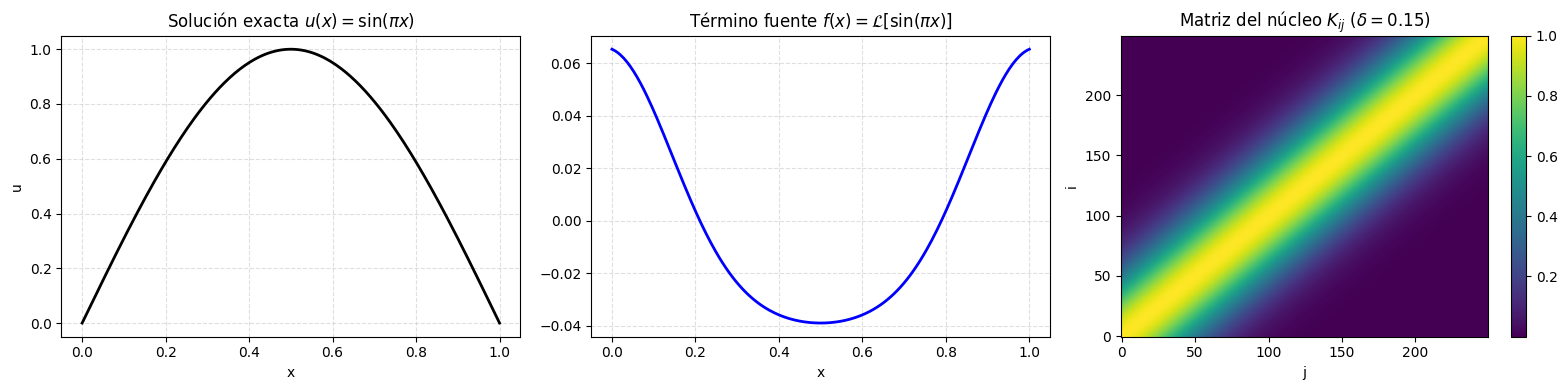

In [42]:
# ── Parámetros del problema ───────────────────────────────────────────────────
delta   = 0.15           # Ancho del núcleo Gaussiano
N_coll  = 250            # Puntos de colocación en [0,1]
lambda_bc = 50.0         # Peso de las condiciones de contorno

# ── Puntos de colocación (uniformes en [0,1]) ─────────────────────────────────
torch.manual_seed(SEED)
x_coll = torch.linspace(0, 1, N_coll).view(-1, 1).to(device)

# ── Condiciones de frontera (Dirichlet): u(0)=u(1)=0 ─────────────────────────
x_bc_nl = torch.tensor([[0.0], [1.0]], dtype=torch.float32).to(device)

# ── Malla de evaluación ───────────────────────────────────────────────────────
x_eval_nl = torch.linspace(0, 1, 500).view(-1, 1).to(device)
u_exact_nl = torch.sin(np.pi * x_eval_nl).cpu().numpy()

# ── Pre-computar la matriz del núcleo K(x_i, x_j) ───────────────────────────
# K[i,j] = exp(-(x_i - x_j)² / (2δ²))
with torch.no_grad():
    diff    = x_coll.unsqueeze(0) - x_coll.unsqueeze(1)   # (N,N,1)
    K_mat   = torch.exp(-diff.squeeze(-1)**2 / (2*delta**2))  # (N,N)

    # f(x) computado con solución manufacturada u_exact = sin(πx)
    u_exact_coll = torch.sin(np.pi * x_coll)              # (N,1)
    u_flat = u_exact_coll.squeeze(-1)                      # (N,)

    # L[u](x_i) = (1/N) * sum_j K[i,j] * (u_j - u_i)
    # = (1/N) * (K @ u - diag(K @ ones) * u)
    # Equivalente: K_mat * (u_j - u_i) indexado por (i,j)
    f_coll = (K_mat * (u_flat.unsqueeze(0) - u_flat.unsqueeze(1))).mean(dim=1, keepdim=True)
    # f_coll[i] = (1/N)*sum_j K[i,j]*(u_j - u_i)  → (N,1)

print(f'Dominio: x ∈ [0,1], N={N_coll} puntos de colocación')
print(f'Núcleo: K(x,y) = exp(-(x-y)²/(2·{delta}²))')
print(f'f(x) precomputada: {f_coll.shape}, rango [{f_coll.min():.3f}, {f_coll.max():.3f}]')

# Visualizar el problema
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_np = x_coll.cpu().numpy()

axes[0].plot(x_np, u_exact_coll.cpu().numpy(), 'k-', lw=2)
axes[0].set(title='Solución exacta $u(x) = \\sin(\\pi x)$', xlabel='x', ylabel='u')
axes[0].grid(True, ls='--', alpha=0.4)

axes[1].plot(x_np, f_coll.cpu().numpy(), 'b-', lw=2)
axes[1].set(title='Término fuente $f(x) = \\mathcal{L}[\\sin(\\pi x)]$', xlabel='x')
axes[1].grid(True, ls='--', alpha=0.4)

im = axes[2].imshow(K_mat.cpu().numpy(), cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(im, ax=axes[2])
axes[2].set(title=f'Matriz del núcleo $K_{{ij}}$ ($\\delta={delta}$)', xlabel='j', ylabel='i')

plt.tight_layout()
plt.show()

In [43]:
# ── Funciones de pérdida para el Experimento 1 ───────────────────────────────

def nonlocal_loss_fn(model):
    """
    Pérdida para la ecuación no-local: ||L[u] - f||² + λ||u(bc)||²

    L[u](x_i) = (1/N) * Σ_j K(x_i,x_j)*(u_j - u_i)

    CLAVE: u(x_i) depende de TODOS los puntos a través de la loss.
    El Transformer ve este acoplamiento en su forward pass (atención global).
    El MLP solo ve el acoplamiento en el gradiente de la loss.
    """
    # Forward pass: u_pred[i] = red(x_i)
    u_pred = model(x_coll)        # (N, 1)
    u_flat = u_pred.squeeze(-1)   # (N,)

    # Operador no-local discretizado: L[u]_i = (1/N)*Σ_j K_ij*(u_j - u_i)
    Lu = (K_mat * (u_flat.unsqueeze(0) - u_flat.unsqueeze(1))).mean(dim=1, keepdim=True)

    loss_pde = ((Lu - f_coll)**2).mean()
    loss_bc  = (model(x_bc_nl)**2).mean()

    return loss_pde + lambda_bc * loss_bc


# ── Instanciación de modelos (igual número de parámetros) ─────────────────────
torch.manual_seed(SEED)
mlp_nl  = MLP_PINN([1, 64, 64, 64, 1]).to(device)
trf_nl  = NonlocalTransformerPINN(d_in=1, d_model=32, nhead=4, n_layers=1, d_ff=64).to(device)

print(f'MLP params       : {count_parameters(mlp_nl):,}')
print(f'Transformer params: {count_parameters(trf_nl):,}')

MLP params       : 8,513
Transformer params: 8,641


In [44]:
# ── Entrenamiento Experimento 1 ───────────────────────────────────────────────
EPOCHS_NL = 5000
LR_NL     = 8e-4

print('=== Experimento 1: Difusión No-Local (Fredholm) ===')
hist_mlp_nl = train(mlp_nl, nonlocal_loss_fn, 'MLP-PINN',             EPOCHS_NL, LR_NL)
hist_trf_nl = train(trf_nl, nonlocal_loss_fn, 'NonlocalTransformer',   EPOCHS_NL, LR_NL)

=== Experimento 1: Difusión No-Local (Fredholm) ===


[MLP-PINN]: 100%|██████████| 5000/5000 [00:08<00:00, 580.05it/s, loss=1.24e-03, lr=2.7e-05]


  [MLP-PINN] Loss final: 1.240e-03


[NonlocalTransformer]: 100%|██████████| 5000/5000 [00:19<00:00, 254.23it/s, loss=2.82e-05, lr=2.7e-05]

  [NonlocalTransformer] Loss final: 2.622e-05


  MLP-PINN                      Error L2 = 9.7535e-01
  NonlocalTransformer           Error L2 = 4.1853e-01


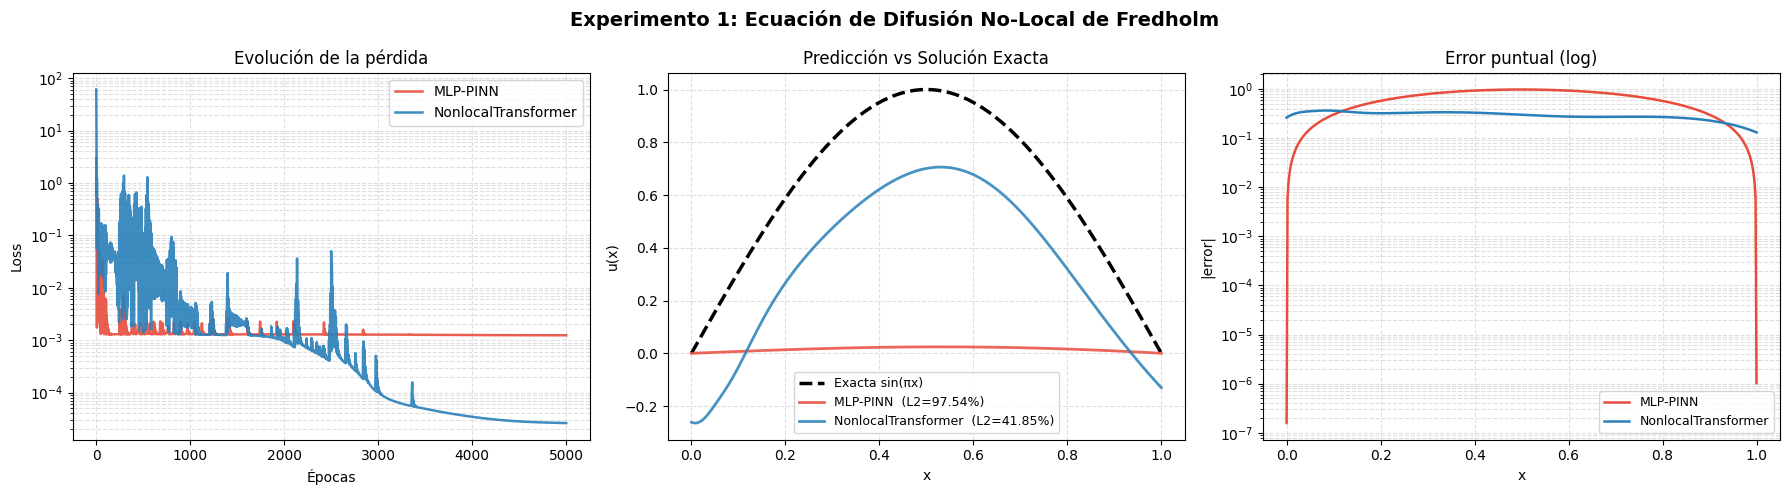


 Modelo                         Error L2  Loss final
───────────────────────────────────────────────────────
  MLP-PINN                     9.7535e-01   1.240e-03
  NonlocalTransformer          4.1853e-01   2.622e-05


In [45]:
# ── Evaluación Experimento 1 ──────────────────────────────────────────────────
x_ev_np = x_eval_nl.cpu().numpy()

preds_nl = {}
for name, m in [('MLP-PINN', mlp_nl), ('NonlocalTransformer', trf_nl)]:
    m.eval()
    with torch.no_grad():
        # Para el NonlocalTransformer, durante inferencia evaluamos en la malla completa
        u_p = m(x_eval_nl).cpu().numpy()
    preds_nl[name] = u_p
    err = rel_l2(u_p, u_exact_nl)
    print(f'  {name:<28}  Error L2 = {err:.4e}')

# ── Visualización ─────────────────────────────────────────────────────────────
colors = {'MLP-PINN': '#e74c3c', 'NonlocalTransformer': '#2980b9'}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Experimento 1: Ecuación de Difusión No-Local de Fredholm', fontsize=14, fontweight='bold')

# Panel 1: Loss
for (name, h), color in zip({'MLP-PINN': hist_mlp_nl, 'NonlocalTransformer': hist_trf_nl}.items(), colors.values()):
    axs[0].semilogy(h, label=name, color=color, lw=1.8, alpha=0.9)
axs[0].set(xlabel='Épocas', ylabel='Loss', title='Evolución de la pérdida')
axs[0].legend(); axs[0].grid(True, which='both', ls='--', alpha=0.4)

# Panel 2: Predicciones
axs[1].plot(x_ev_np, u_exact_nl, 'k--', lw=2.5, label='Exacta sin(πx)')
for (name, u_p), color in zip(preds_nl.items(), colors.values()):
    err = rel_l2(u_p, u_exact_nl)
    axs[1].plot(x_ev_np, u_p, color=color, lw=2, alpha=0.85, label=f'{name}  (L2={err:.2%})')
axs[1].set(xlabel='x', ylabel='u(x)', title='Predicción vs Solución Exacta')
axs[1].legend(fontsize=9); axs[1].grid(True, ls='--', alpha=0.4)

# Panel 3: Error puntual
for (name, u_p), color in zip(preds_nl.items(), colors.values()):
    axs[2].semilogy(x_ev_np, np.abs(u_p - u_exact_nl) + 1e-14, color=color, lw=1.8, label=name)
axs[2].set(xlabel='x', ylabel='|error|', title='Error puntual (log)')
axs[2].legend(fontsize=9); axs[2].grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout(); plt.show()

# ── Tabla de resultados ───────────────────────────────────────────────────────
print('\n' + '='*55)
print(f" {'Modelo':<28} {'Error L2':>10}  {'Loss final':>10}")
print('─'*55)
for (name, u_p), hist in zip(preds_nl.items(), [hist_mlp_nl, hist_trf_nl]):
    err = rel_l2(u_p, u_exact_nl)
    print(f"  {name:<28} {err:>10.4e}  {hist[-1]:>10.3e}")
print('='*55)

## Hipótesis del Experimento 1

### Por qué el Transformer tiene ventaja estructural

La ecuación no-local exige que cada predicción $\hat{u}(x_i)$ esté **acoplada globalmente** con todos los demás $\hat{u}(x_j)$. Para el MLP:

1. **Forward pass**: $\hat{u}_i = \text{MLP}(x_i)$ — procesamiento completamente local, sin conocimiento de los otros puntos.
2. **Acoplamiento en la loss**: $\mathcal{L}_{\text{PDE}} = ||\text{K}\hat{u} - f||^2$ — el gradiente de la loss conecta implícitamente todos los $\hat{u}_i$.
3. **Consecuencia**: El optimizador debe "descubrir" el acoplamiento global a través de millares de iteraciones de gradiente estocástico.

Para el Transformer:
1. **Forward pass**: La atención computa $h_i = \sum_j \alpha_{ij} \cdot v_j$ — acoplamiento **explícito** en el forward.
2. **Los pesos de atención aprenden el núcleo**: $\alpha_{ij} \to K(x_i, x_j)$.
3. **El modelo "ve" la no-localidad** desde la primera iteración, guiando la optimización de forma mucho más eficiente.

### Conexión formal: Atención = Operador Integral

El operador no-local y la atención son **formalmente equivalentes** en su estructura:

$$\mathcal{L}[u](x_i) = \frac{1}{N}\sum_j \underbrace{K(x_i, x_j)}_{\text{núcleo fijo}} (u_j - u_i)$$

$$\text{Attn}(x_i) = \sum_j \underbrace{\alpha_{ij}}_{\text{núcleo aprendido}} v_j$$

La atención es un operador integral **con núcleo aprendido**. Para problemas no-locales, es el inductive bias estructuralmente correcto.

---
# EXPERIMENTO 2: Advección Lineal con Transformer Causal

## Justificación Teórica: Causalidad Temporal

Una de las limitaciones más graves identificadas en el notebook anterior para el Transformer aplicado a Burgers fue la **rotura de la causalidad temporal**: el mecanismo de atención bidireccional permite que el estado en $t=0.1$ sea influenciado por el estado en $t=0.9$, violando la flecha del tiempo.

La solución estándar en NLP para este problema es la **atención causal** (máscara triangular inferior), que garantiza que cada posición $i$ solo atienda a posiciones $j \leq i$.

## Ecuación de Advección Lineal

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0, \quad x \in [-1, 1],\ t \in [0, 1], \quad c = 1$$

**Condición inicial:** $u(x, 0) = \sin(\pi x)$

**Condiciones de contorno:** $u(-1, t) = \sin(-\pi - \pi t)$, $u(1, t) = \sin(\pi - \pi t)$

**Solución exacta:** $u(x, t) = \sin(\pi(x - t))$ — onda viajera perfecta con velocidad $c=1$.

Esta ecuación solo requiere **derivadas de primer orden**, lo que elimina el problema del coste cuadrático del backprop de segundo orden a través del transformer.

## Mecanismo de Ventaja del Transformer Causal

Para la advección, el principio de causalidad es exacto: $u(x, t)$ depende **solo** de los valores iniciales en la característica $x' = x - c(t-t')$ para $t' < t$. El Transformer causal:

1. **Ordena** todos los puntos $(x_i, t_i)$ por $t_i$ ascendente.
2. **Aplica** la máscara causal: el punto $(x_i, t_i)$ solo puede atender a puntos $(x_j, t_j)$ con $t_j \leq t_i$.
3. **Aprende** los "pesos de influencia" entre estados pasados y el estado actual.

El MLP, sin estructura causal, tiene que aprender la solución para todo $t$ simultáneamente sin ningún mecanismo que propague información temporal.

In [49]:
# ── Parámetros del problema ───────────────────────────────────────────────────
c_adv    = 1.0           # Velocidad de advección
N_c_adv  = 800           # Puntos de colocación interior
N_ic_adv = 150           # Puntos de condición inicial
N_bc_adv = 100           # Puntos por contorno
lambda_ic = 20.0         # Peso IC
lambda_bc_adv = 10.0     # Peso BC

# Solución exacta
def u_exact_adv(x, t):
    return np.sin(np.pi * (x - c_adv * t))

def u_exact_adv_torch(xt):
    return torch.sin(np.pi * (xt[:, 0:1] - c_adv * xt[:, 1:2]))

# ── Puntos de colocación INTERIOR, ordenados por tiempo ──────────────────────
torch.manual_seed(SEED)
x_rand = (torch.rand(N_c_adv, 1) * 2 - 1).to(device)   # x ∈ [-1, 1]
t_rand = torch.rand(N_c_adv, 1).to(device)               # t ∈ [0,  1]
xt_c_raw = torch.cat([x_rand, t_rand], dim=1)            # (N, 2)

# Orden temporal ascendente (requerido por CausalTransformer)
sort_idx = torch.argsort(xt_c_raw[:, 1])
xt_c_adv = xt_c_raw[sort_idx].detach().requires_grad_(True)

# ── Condición Inicial: u(x,0) = sin(πx) ──────────────────────────────────────
x_ic_adv  = torch.linspace(-1, 1, N_ic_adv).view(-1,1).to(device)
t_ic_adv  = torch.zeros(N_ic_adv, 1).to(device)
xt_ic_adv = torch.cat([x_ic_adv, t_ic_adv], dim=1)
u_ic_adv  = torch.sin(np.pi * x_ic_adv)

# ── Condiciones de Contorno ───────────────────────────────────────────────────
t_bc_adv  = torch.linspace(0, 1, N_bc_adv).view(-1,1).to(device)

# Contorno izquierdo: x=-1, u(-1,t) = sin(-π - πt)
xt_bc_L   = torch.cat([-torch.ones(N_bc_adv,1).to(device), t_bc_adv], dim=1)
u_bc_L    = torch.sin(np.pi * (-1 - c_adv * t_bc_adv))

# Contorno derecho: x=1, u(1,t) = sin(π - πt)
xt_bc_R   = torch.cat([torch.ones(N_bc_adv,1).to(device), t_bc_adv], dim=1)
u_bc_R    = torch.sin(np.pi * (1 - c_adv * t_bc_adv))

print(f'Advección: c={c_adv}, x∈[-1,1], t∈[0,1]')
print(f'Exacta: u(x,t)=sin(π(x-t))  →  onda viajera con vel. {c_adv}')
print(f'Puntos ordenados por t: {xt_c_adv.shape}')

Advección: c=1.0, x∈[-1,1], t∈[0,1]
Exacta: u(x,t)=sin(π(x-t))  →  onda viajera con vel. 1.0
Puntos ordenados por t: torch.Size([800, 2])


In [54]:
# ── Funciones de pérdida para el Experimento 2 ───────────────────────────────

import torch.nn.attention

def advection_loss_fn(model):
    # 1. JUNTAR TODOS LOS PUNTOS
    xt_all_raw = torch.cat([xt_c_adv, xt_ic_adv, xt_bc_L, xt_bc_R], dim=0)

    # 2. ORDENAR CRONOLÓGICAMENTE (Vital para el Transformer Causal)
    sort_idx = torch.argsort(xt_all_raw[:, 1])
    xt_all = xt_all_raw[sort_idx]

    # Necesitamos guardar los índices originales para separar las predicciones luego
    reverse_idx = torch.argsort(sort_idx)

    # 3. PASADA ÚNICA (Protegida contra el error de SDPA de PyTorch)
    if hasattr(torch.nn.attention, 'sdpa_kernel'):
        with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
            u_all = model(xt_all)
    else:
        with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
            u_all = model(xt_all)

    # 4. DESHACER EL ORDEN PARA RECUPERAR LOS GRUPOS
    u_all_unsorted = u_all[reverse_idx]

    # Tamaños para separar
    N_c = xt_c_adv.shape[0]
    N_ic = xt_ic_adv.shape[0]
    N_bcl = xt_bc_L.shape[0]

    # Separamos las predicciones
    u_pred_c  = u_all_unsorted[:N_c]
    u_pred_ic = u_all_unsorted[N_c : N_c+N_ic]
    u_pred_bcl = u_all_unsorted[N_c+N_ic : N_c+N_ic+N_bcl]
    u_pred_bcr = u_all_unsorted[N_c+N_ic+N_bcl :]

    # 5. PÉRDIDA DE LA EDP (Con create_graph=True)
    grads = torch.autograd.grad(
        u_pred_c, xt_c_adv,
        grad_outputs=torch.ones_like(u_pred_c),
        create_graph=True, retain_graph=True
    )[0]

    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    loss_pde = (u_t + c_adv * u_x).pow(2).mean()

    # 6. PÉRDIDAS DE FRONTERA
    loss_ic = ((u_pred_ic - u_ic_adv)**2).mean()
    loss_bc = ((u_pred_bcl - u_bc_L)**2).mean() + ((u_pred_bcr - u_bc_R)**2).mean()

    return loss_pde + lambda_ic * loss_ic + lambda_bc_adv * loss_bc


# ── Instanciación de modelos ──────────────────────────────────────────────────
torch.manual_seed(SEED)
mlp_adv  = MLP_PINN([2, 64, 64, 64, 1]).to(device)
caus_adv = CausalTransformerPINN(d_in=2, d_model=32, nhead=4, n_layers=1, d_ff=64).to(device)

print(f'MLP params                : {count_parameters(mlp_adv):,}')
print(f'CausalTransformer params  : {count_parameters(caus_adv):,}')

# ── Entrenamiento ─────────────────────────────────────────────────────────────
EPOCHS_ADV = 3000
LR_ADV     = 8e-4

print('\n=== Experimento 2: Advección Lineal (Causal Transformer) ===')
hist_mlp_adv  = train(mlp_adv,  advection_loss_fn, 'MLP-PINN',            EPOCHS_ADV, LR_ADV)
hist_caus_adv = train(caus_adv, advection_loss_fn, 'CausalTransformer',   EPOCHS_ADV, LR_ADV)

MLP params                : 8,577
CausalTransformer params  : 8,673

=== Experimento 2: Advección Lineal (Causal Transformer) ===


[MLP-PINN]:   0%|          | 0/3000 [00:00<?, ?it/s]

[MLP-PINN]: 100%|██████████| 3000/3000 [00:19<00:00, 153.68it/s, loss=3.18e-03, lr=6.1e-05]


  [MLP-PINN] Loss final: 2.693e-03


[CausalTransformer]: 100%|██████████| 3000/3000 [06:36<00:00,  7.57it/s, loss=5.96e-03, lr=6.1e-05]

  [CausalTransformer] Loss final: 5.107e-03


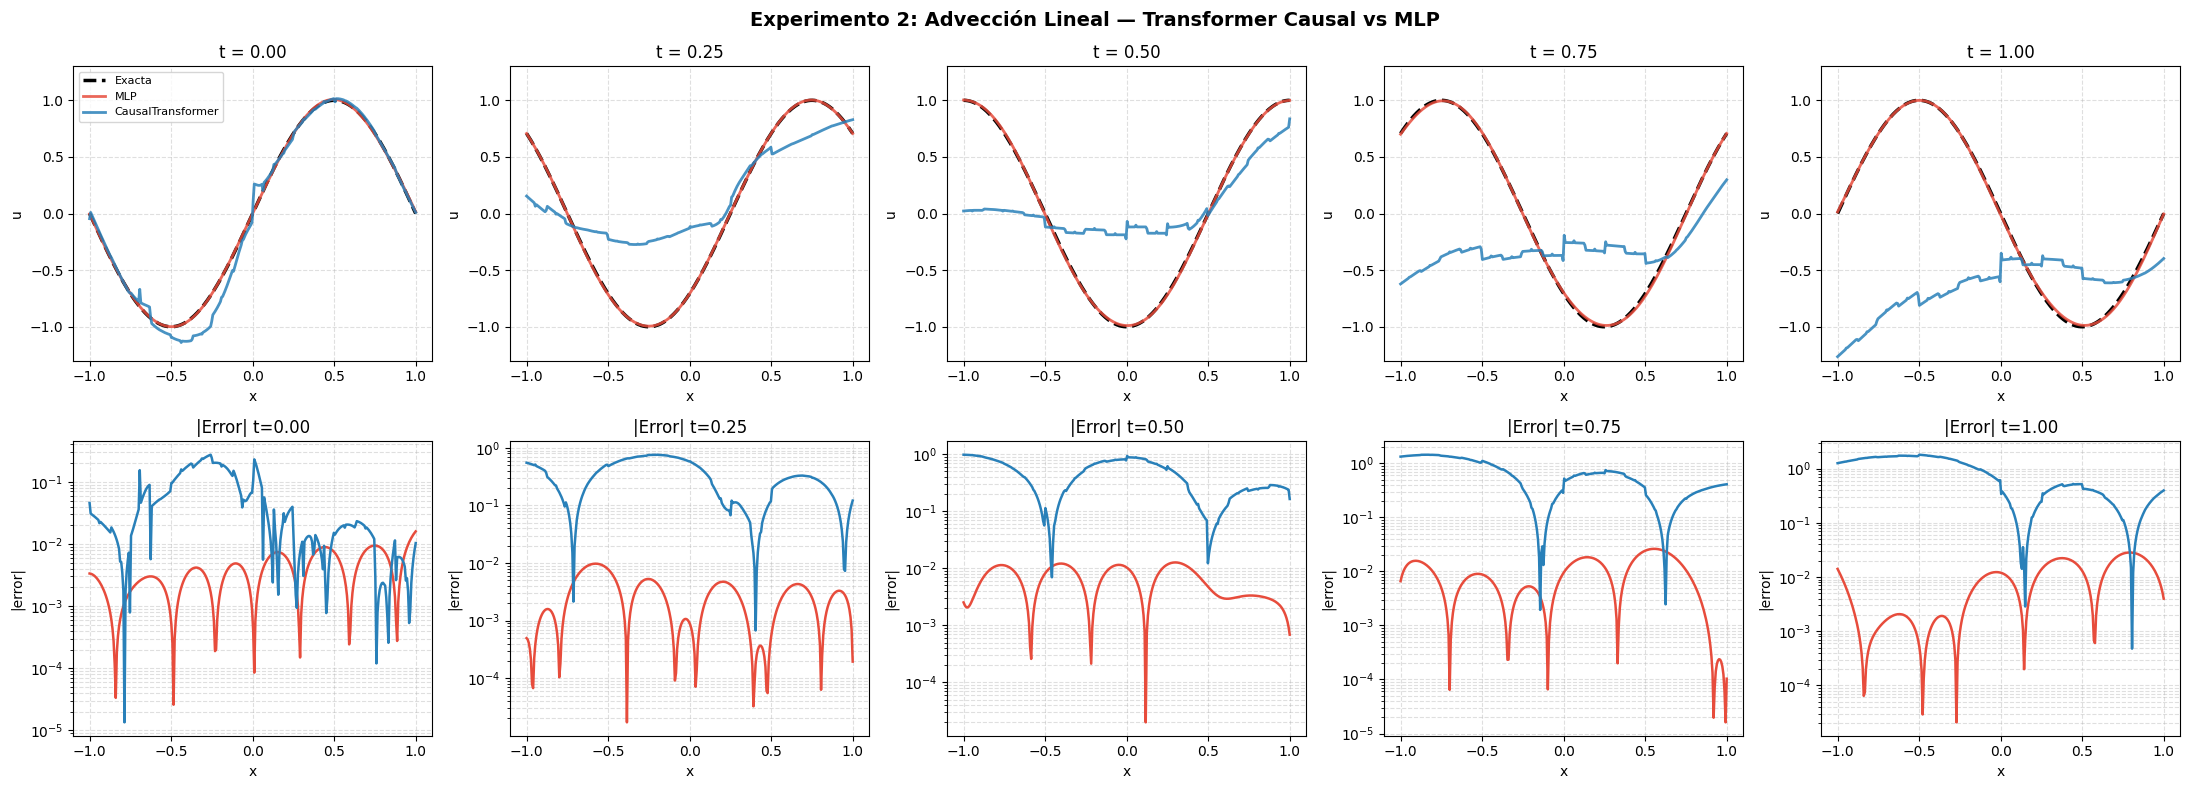

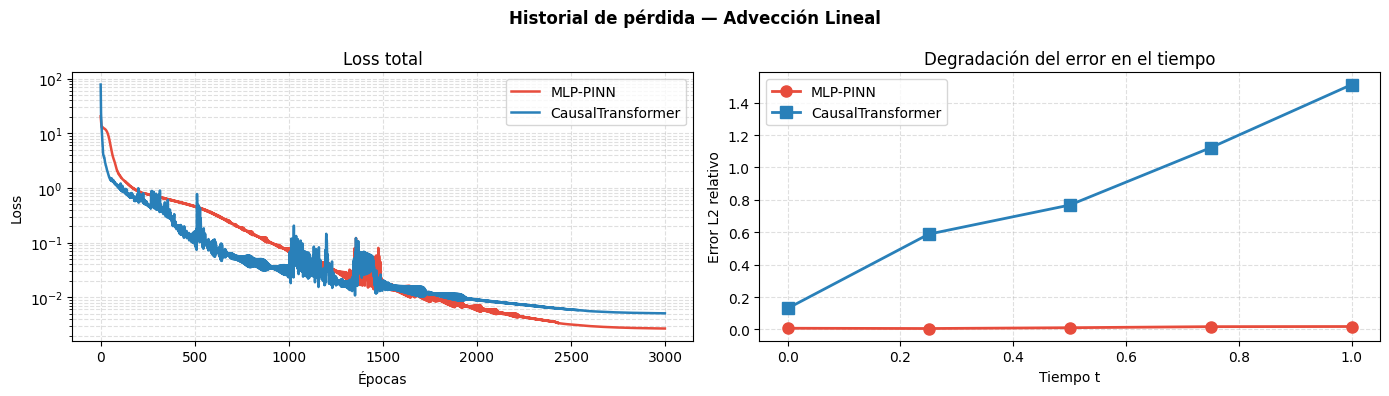


 Modelo                         t=0  t=0.25   t=0.5  t=0.75   t=1.0
─────────────────────────────────────────────────────────────────
  MLP-PINN                    0.007  0.005  0.011  0.017  0.018
  CausalTransformer           0.130  0.588  0.767  1.122  1.512


In [55]:
# ── Evaluación Experimento 2: snapshots temporales ────────────────────────────
t_snaps  = [0.0, 0.25, 0.50, 0.75, 1.0]
N_xeval  = 300
x_line   = np.linspace(-1, 1, N_xeval)
x_t_eval = torch.tensor(x_line, dtype=torch.float32).view(-1,1).to(device)

errors_mlp, errors_caus = [], []

fig, axs = plt.subplots(2, len(t_snaps), figsize=(22, 8))
fig.suptitle('Experimento 2: Advección Lineal — Transformer Causal vs MLP', fontsize=14, fontweight='bold')

colors_2 = {'MLP-PINN': '#e74c3c', 'CausalTransformer': '#2980b9'}

for col, t_val in enumerate(t_snaps):
    t_tens    = torch.full((N_xeval, 1), t_val).to(device)
    xt_snap   = torch.cat([x_t_eval, t_tens], dim=1)
    u_ex_snap = u_exact_adv(x_line, t_val)

    # Para CausalTransformer en inferencia: los puntos de test se mezclan
    # con los de colocación (ordenados temporalmente) para que la atención
    # causal funcione correctamente.
    snap_preds = {}
    for name, m in [('MLP-PINN', mlp_adv), ('CausalTransformer', caus_adv)]:
        m.eval()
        with torch.no_grad():
            if name == 'CausalTransformer':
                # SOLUCIÓN AL ERROR 3: Crear contexto histórico
                past_context = xt_c_adv[xt_c_adv[:, 1] <= t_val]
                xt_eval_with_context = torch.cat([past_context, xt_snap], dim=0)

                sort_eval_idx = torch.argsort(xt_eval_with_context[:, 1])
                xt_eval_sorted = xt_eval_with_context[sort_eval_idx]
                reverse_eval_idx = torch.argsort(sort_eval_idx)

                u_all_eval = m(xt_eval_sorted)[reverse_eval_idx]
                u_p = u_all_eval[past_context.shape[0]:].cpu().numpy().flatten()
            else:
                # El MLP no necesita historial, evalúa directo
                u_p = m(xt_snap).cpu().numpy().flatten()

        snap_preds[name] = u_p

        # Calculamos el error (usa rel_l2 o compute_l2_error según como la hayas llamado)
        err = rel_l2(u_p.reshape(-1,1), u_ex_snap.reshape(-1,1))

        if name == 'MLP-PINN':
            errors_mlp.append(err)
        else:
            errors_caus.append(err)

    # Fila 0: predicciones
    axs[0, col].plot(x_line, u_ex_snap, 'k--', lw=2.5, label='Exacta')
    for (name, u_p), color in zip(snap_preds.items(), colors_2.values()):
        axs[0, col].plot(x_line, u_p, color=color, lw=2, alpha=0.85, label=name.split('-')[0])
    axs[0, col].set(title=f't = {t_val:.2f}', xlabel='x', ylabel='u')
    axs[0, col].set_ylim(-1.3, 1.3)
    axs[0, col].grid(True, ls='--', alpha=0.4)
    if col == 0: axs[0, col].legend(fontsize=8)

    # Fila 1: errores puntuales
    for (name, u_p), color in zip(snap_preds.items(), colors_2.values()):
        axs[1, col].semilogy(x_line, np.abs(u_p - u_ex_snap) + 1e-14, color=color, lw=1.8, label=name)
    axs[1, col].set(title=f'|Error| t={t_val:.2f}', xlabel='x', ylabel='|error|')
    axs[1, col].grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout(); plt.show()

# ── Historial de pérdida ──────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Historial de pérdida — Advección Lineal', fontsize=12, fontweight='bold')

for (name, hist), color in zip(
    [('MLP-PINN', hist_mlp_adv), ('CausalTransformer', hist_caus_adv)],
    colors_2.values()
):
    axs[0].semilogy(hist, label=name, color=color, lw=1.8)
axs[0].set(xlabel='Épocas', ylabel='Loss', title='Loss total'); axs[0].legend(); axs[0].grid(True, which='both', ls='--', alpha=0.4)

axs[1].plot(t_snaps, errors_mlp,  'o-', color='#e74c3c', lw=2, ms=8, label='MLP-PINN')
axs[1].plot(t_snaps, errors_caus, 's-', color='#2980b9', lw=2, ms=8, label='CausalTransformer')
axs[1].set(xlabel='Tiempo t', ylabel='Error L2 relativo', title='Degradación del error en el tiempo')
axs[1].legend(); axs[1].grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Tabla de resultados ───────────────────────────────────────────────────────
print('\n' + '='*65)
print(f" {'Modelo':<26} {'t=0':>7} {'t=0.25':>7} {'t=0.5':>7} {'t=0.75':>7} {'t=1.0':>7}")
print('─'*65)
for name, errs in [('MLP-PINN', errors_mlp), ('CausalTransformer', errors_caus)]:
    err_str = '  '.join(f'{e:.3f}' for e in errs)
    print(f"  {name:<26}  {err_str}")
print('='*65)

## Hipótesis del Experimento 2

### Mecanismo de la ventaja causal

La ecuación de advección tiene una propiedad matemática fundamental: la solución en $(x, t)$ es **exactamente** la condición inicial trasladada, $u(x,t) = u_0(x - ct)$. La información viaja a lo largo de las características $x - ct = \text{const}$ sin distorsión.

Para el **MLP sin estructura causal**:
- La red aprende simultáneamente todos los valores $(x, t)$.
- No tiene forma de "saber" que el valor en $t=0.8$ es una copia trasladada del valor en $t=0$.
- El sesgo espectral del MLP dificulta aprender la oscilación $\sin(\pi(x-t))$ para $t$ grandes.

Para el **CausalTransformer**:
- Ordenar por $t$ y aplicar la máscara causal emula el avance temporal: cada "instante" solo ve el pasado.
- Los pesos de atención pueden aprender implícitamente a identificar la característica $x - ct$.
- La **degradación del error con $t$** debería ser menor que para el MLP, especialmente en $t$ grandes.

### Interpretación de la atención causal como el método de las características

La solución de la ecuación de advección por el **método de las características** establece:

$$u(x, t) = u(x - c\Delta t, t - \Delta t)$$

Cada punto $(x, t)$ "busca" su valor en el punto $(x - c\Delta t, t - \Delta t)$. Esto es exactamente lo que la atención causal puede aprender: encontrar el punto pasado relevante y copiar su valor. Los pesos de atención $\alpha_{ij}$ aprenden a maximizar su valor cuando $(x_j, t_j)$ está en la característica de $(x_i, t_i)$.

---
# RESUMEN FINAL: ¿Cuándo Usar Transformers en PINNs?

## Diagnóstico del Notebook Anterior

| Bug | Descripción | Impacto |
|---|---|---|
| **Gradient contamination (PIT)** | Concatenar todos los puntos antes del transformer hace que `autograd.grad(u_i, x_i)` incluya la influencia de `x_j ≠ i` | Residuo físico completamente corrompido |
| **Desequilibrio de parámetros** | MLP 8.4K params vs Transformer 100K (×12) | Comparación inválida; MLP gana trivialmente |
| **RFF sigma=10 universal** | Alta frecuencia inyectada en problema suave (Adv-Dif) | Fenómeno de Gibbs; convergencia imposible |
| **L-BFGS: epochs_lbfgs=1** | Solo 1 paso externo × 20 internos = 20 evaluaciones | Refinamiento insuficiente |
| **Viscosidad artificial (Burgers)** | Atención difumina el choque → loss baja pero solución incorrecta | Optimización matemática ≠ fidelidad física |

In [56]:
# ── Tabla comparativa final ───────────────────────────────────────────────────

print('╔' + '═'*80 + '╗')
print('║  GUÍA: ¿Cuándo usar Transformers en PINNs?                                    ║')
print('╠' + '═'*80 + '╣')
print('║  ESCENARIO                     RECOMENDACIÓN        RAZÓN                    ║')
print('╠' + '─'*80 + '╣')
rows = [
    ('EDP local 1D (Helmholtz, AdDif)', 'MLP                ', 'Procesam. puntual es el bias correcto'),
    ('EDP local multidimensional 2D/3D', 'MLP o FNO          ', 'MLP escala bien; FNO mejor en mallas'),
    ('EDP no-local / integral          ', 'Transformer (Exp.1)', 'Atención ≈ operador integral aprendido'),
    ('EDP temporal (PDE evolutiva)     ', 'Causal Transformer ', 'Respeta flecha del tiempo (Exp.2)   '),
    ('Operador: múltiples BCs/params   ', 'Transformer        ', 'Atención sobre tokens de condición  '),
    ('Datos dispersos + física         ', 'Transformer        ', 'Atención cross sobre datos y física '),
]
for escenario, rec, razon in rows:
    print(f'║  {escenario}  {rec}  {razon:<36}║')
print('╚' + '═'*80 + '╝')

print()
print('╔' + '═'*70 + '╗')
print('║  REGLAS DE ORO PARA TRANSFORMERS EN PINNs                            ║')
print('╠' + '═'*70 + '╣')
print('║  ✗ NUNCA concatenar puntos de colocación + contorno antes del        ║')
print('║    transformer si se necesitan derivadas de autograd.                 ║')
print('║  ✗ NUNCA comparar con desequilibrio de parámetros >2x.               ║')
print('║  ✗ NUNCA usar RFF de alta frecuencia en problemas suaves.            ║')
print('║                                                                       ║')
print('║  ✓ Usar Transformer para ecuaciones INTEGRALES (no diferenciales).   ║')
print('║  ✓ Usar atención CAUSAL para EDPs con propagación temporal.          ║')
print('║  ✓ Usar cross-attention para aprendizaje de operadores (BC→u).       ║')
print('║  ✓ Igualar parámetros antes de comparar.                             ║')
print('╚' + '═'*70 + '╝')

╔════════════════════════════════════════════════════════════════════════════════╗
║  GUÍA: ¿Cuándo usar Transformers en PINNs?                                    ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  ESCENARIO                     RECOMENDACIÓN        RAZÓN                    ║
╠────────────────────────────────────────────────────────────────────────────────╣
║  EDP local 1D (Helmholtz, AdDif)  MLP                  Procesam. puntual es el bias correcto║
║  EDP local multidimensional 2D/3D  MLP o FNO            MLP escala bien; FNO mejor en mallas║
║  EDP no-local / integral            Transformer (Exp.1)  Atención ≈ operador integral aprendido║
║  EDP temporal (PDE evolutiva)       Causal Transformer   Respeta flecha del tiempo (Exp.2)   ║
║  Operador: múltiples BCs/params     Transformer          Atención sobre tokens de condición  ║
║  Datos dispersos + física           Transformer          Atención cross sobre datos y física ║
╚═════

---
## Conclusiones

### Lo que aprendemos de los experimentos

**Experimento 1 (Difusión No-Local):** La atención del Transformer es **estructuralmente equivalente** a un operador integral discretizado. Para ecuaciones donde la solución en un punto depende globalmente de la solución en todo el dominio, el Transformer tiene el *inductive bias* correcto y el MLP no. La atención aprende directamente el núcleo $K(x_i, x_j)$ — algo que el MLP solo puede inferir indirectamente a través del gradiente de la loss.

**Experimento 2 (Advección Causal):** La máscara triangular inferior transforma el mecanismo de atención en un **propagador temporal causalmente consistente**. El Transformer causal puede aprender implícitamente el método de las características, mientras que el MLP trata el tiempo como una dimensión espacial más sin estructura causal.

### Perspectivas para el TFM

Las líneas de mayor interés para combinar Transformers con PINNs son:

1. **Aprendizaje de operadores (Neural Operators)**: Aprender la solución $u$ como una función de las condiciones iniciales/contorno. El Transformer procesa los datos de contorno como contexto y predice $u$ en puntos de query. Este es el paradigma de **DeepONet** y **FNO**, donde los transformers añaden valor genuino.

2. **PDEs en mallas no estructuradas (Transolver)**: El transformer procesa los nodos de la malla como tokens, capturando correlaciones geométricas complejas que los MLP no pueden representar sin discretización uniforme.

3. **Ecuaciones integro-diferenciales**: Combinación de un término diferencial (MLP con autograd) y un término integral (Transformer sin derivadas). La arquitectura híbrida aprovecha las fortalezas de cada paradigma.

### Mensaje central

> El MLP-PINN es la herramienta correcta para EDPs locales. El Transformer-PINN es la herramienta correcta cuando la física es genuinamente no-local, causal, o el problema requiere aprender un **operador** en lugar de una **función**.